<a href="https://colab.research.google.com/github/bemourasilva-png/estatistica-students-performance/blob/main/notebook/analise_students_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importação e exploração do DataSet

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = 'https://raw.githubusercontent.com/bemourasilva-png/estatistica-students-performance/main/data/StudentsPerformance.csv'
base = pd.read_csv(url)
base.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
base.shape

(1000, 8)

In [8]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
base.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [10]:
base.describe().round(2)

,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [11]:
categoricas = ['gender', 'race/ethnicity', 'parental level of education',
               'lunch', 'test preparation course']
for i in categoricas:
 agrupado = base.groupby([i]).size()
 print(agrupado)
 print('-'*40)

gender
female    518
male      482
dtype: int64
----------------------------------------
race/ethnicity
group A     89
group B    190
group C    319
group D    262
group E    140
dtype: int64
----------------------------------------
parental level of education
associate's degree    222
bachelor's degree     118
high school           196
master's degree        59
some college          226
some high school      179
dtype: int64
----------------------------------------
lunch
free/reduced    355
standard        645
dtype: int64
----------------------------------------
test preparation course
completed    358
none         642
dtype: int64
----------------------------------------


Conclusões:
*   O data set possui 1000 registros para 8 variaveis, sendo 5 categóricas - gênero, raça/etnia, nivel de educação dos pais, almoço e curso preparatório - e 3 numéricas - nota de matemática, nota de leitura e nota de escrita;
*   Não tem possui valores nulos;


*   As notas variam de 0 a 100







EDA e Amostragem

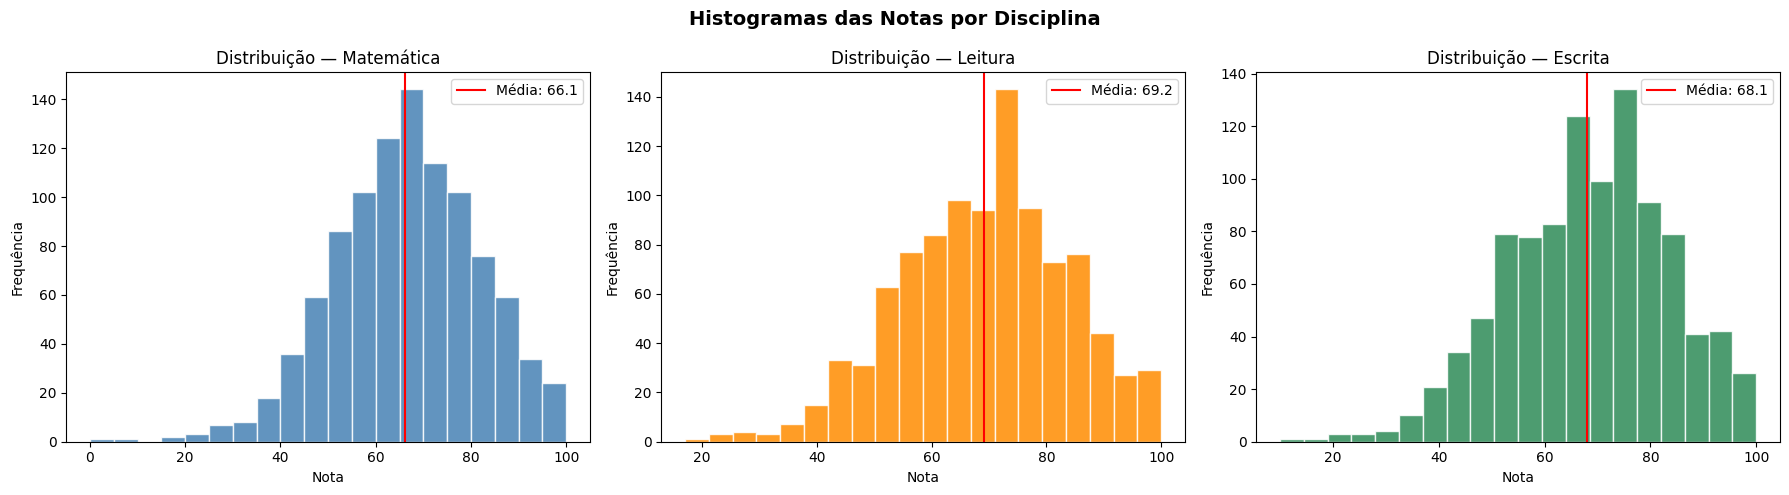

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disciplinas = ['math score', 'reading score', 'writing score']
titulos = ['Matemática', 'Leitura', 'Escrita']
cores = ['steelblue', 'darkorange', 'seagreen']

for i, (col, titulo, cor) in enumerate(zip(disciplinas, titulos, cores)):
    axes[i].hist(base[col], bins=20, color=cor, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribuição — {titulo}')
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Frequência')
    axes[i].axvline(base[col].mean(), color='red', linestyle='--', label=f'Média: {base[col].mean():.1f}')
    axes[i].legend()

plt.suptitle('Histogramas das Notas por Disciplina', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
amostra_simples = base.sample(frac=0.1, random_state=42)
print(f"Tamanho da amostra: {len(amostra_simples)}")
print(f"\nMédia das notas na amostra:")
print(amostra_simples[disciplinas].mean().round(2))

Tamanho da amostra: 100

Média das notas na amostra:
math score       63.95
reading score    67.29
writing score    66.03
dtype: float64


/tmp/ipykernel_2711/3583901382.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='gender', y=col, palette='muted', ax=axes[i])
/tmp/ipykernel_2711/3583901382.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='gender', y=col, palette='muted', ax=axes[i])
/tmp/ipykernel_2711/3583901382.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='gender', y=col, palette='muted', ax=axes[i])


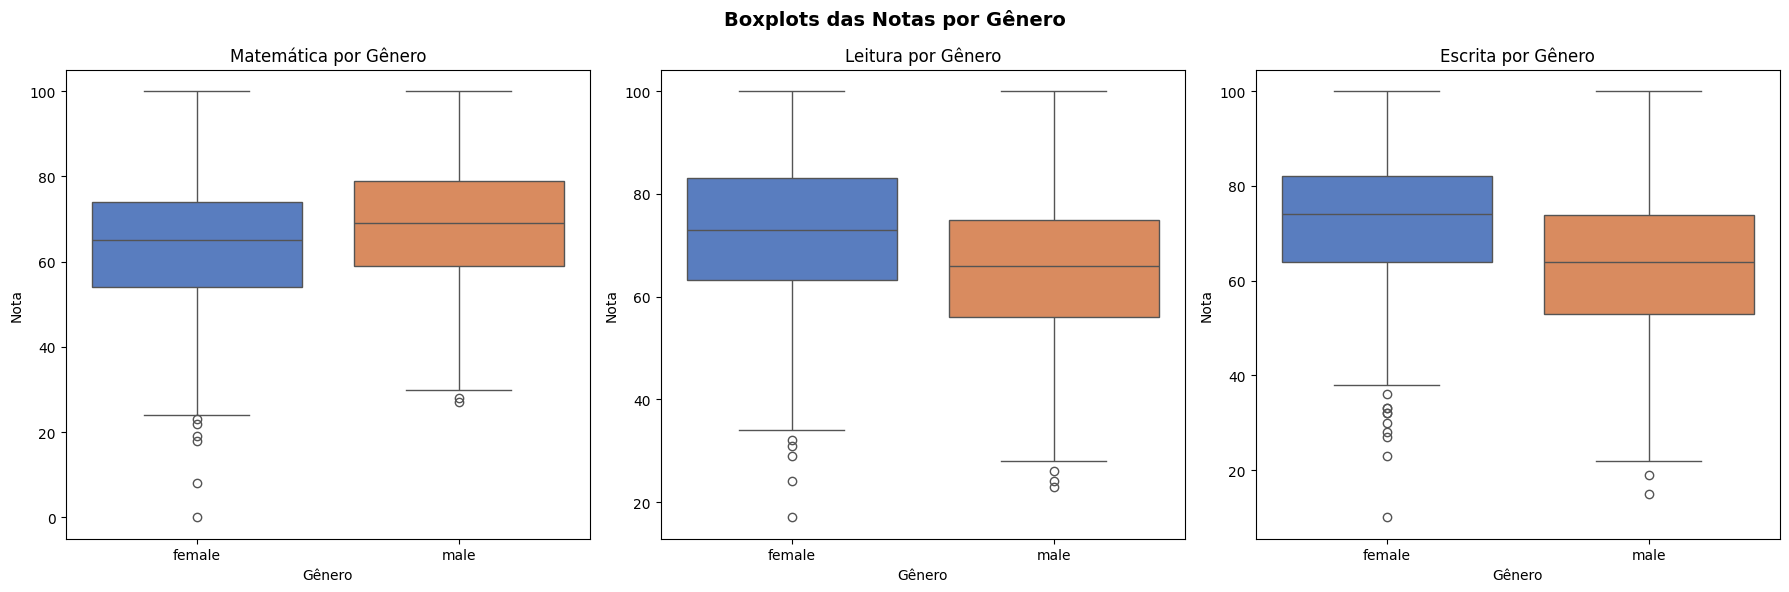

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, titulo) in enumerate(zip(disciplinas, titulos)):
    sns.boxplot(data=base, x='gender', y=col, palette='muted', ax=axes[i])
    axes[i].set_title(f'{titulo} por Gênero')
    axes[i].set_xlabel('Gênero')
    axes[i].set_ylabel('Nota')

plt.suptitle('Boxplots das Notas por Gênero', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2711/2708089383.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='test preparation course', y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_2711/2708089383.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='test preparation course', y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_2711/2708089383.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='test preparation course', y=col, palette='Set2', ax=axes[i])


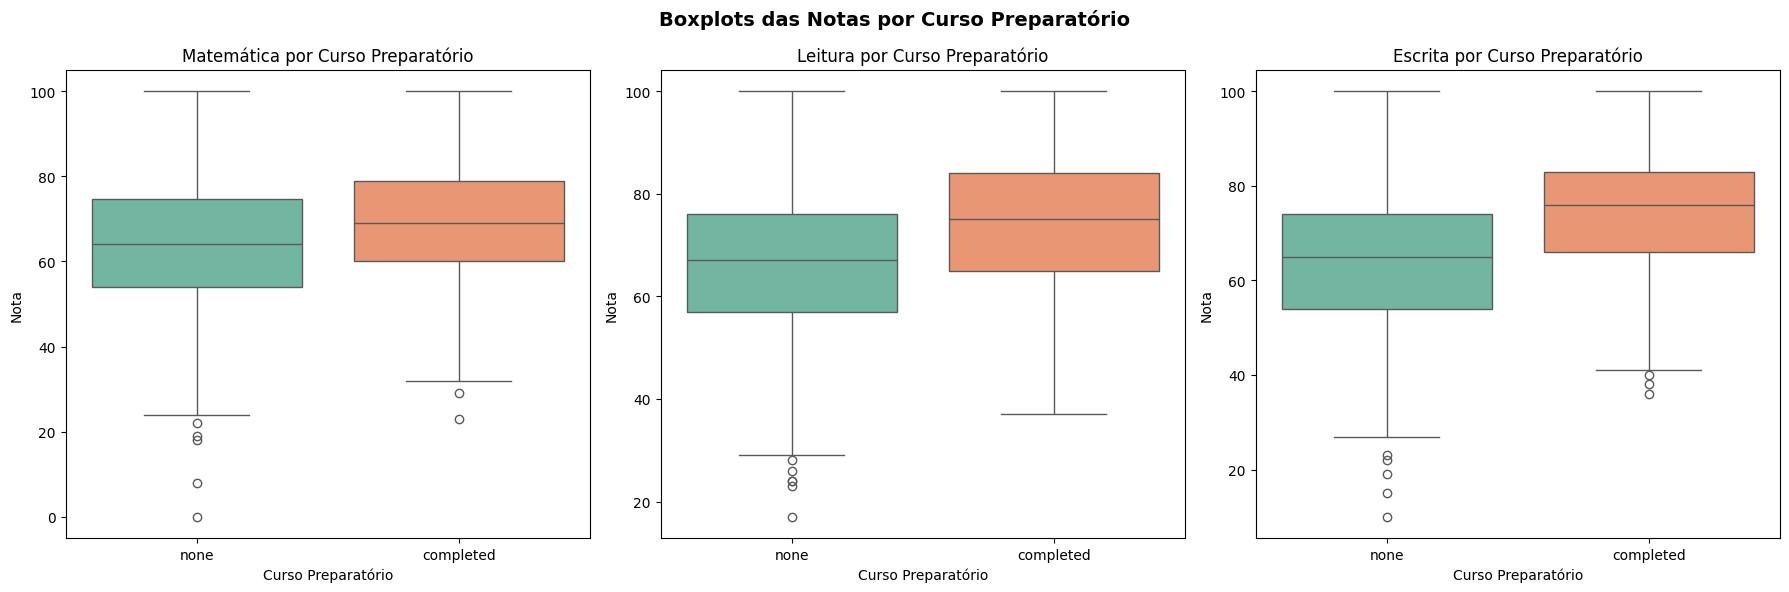

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, titulo) in enumerate(zip(disciplinas, titulos)):
    sns.boxplot(data=base, x='test preparation course', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{titulo} por Curso Preparatório')
    axes[i].set_xlabel('Curso Preparatório')
    axes[i].set_ylabel('Nota')

plt.suptitle('Boxplots das Notas por Curso Preparatório', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

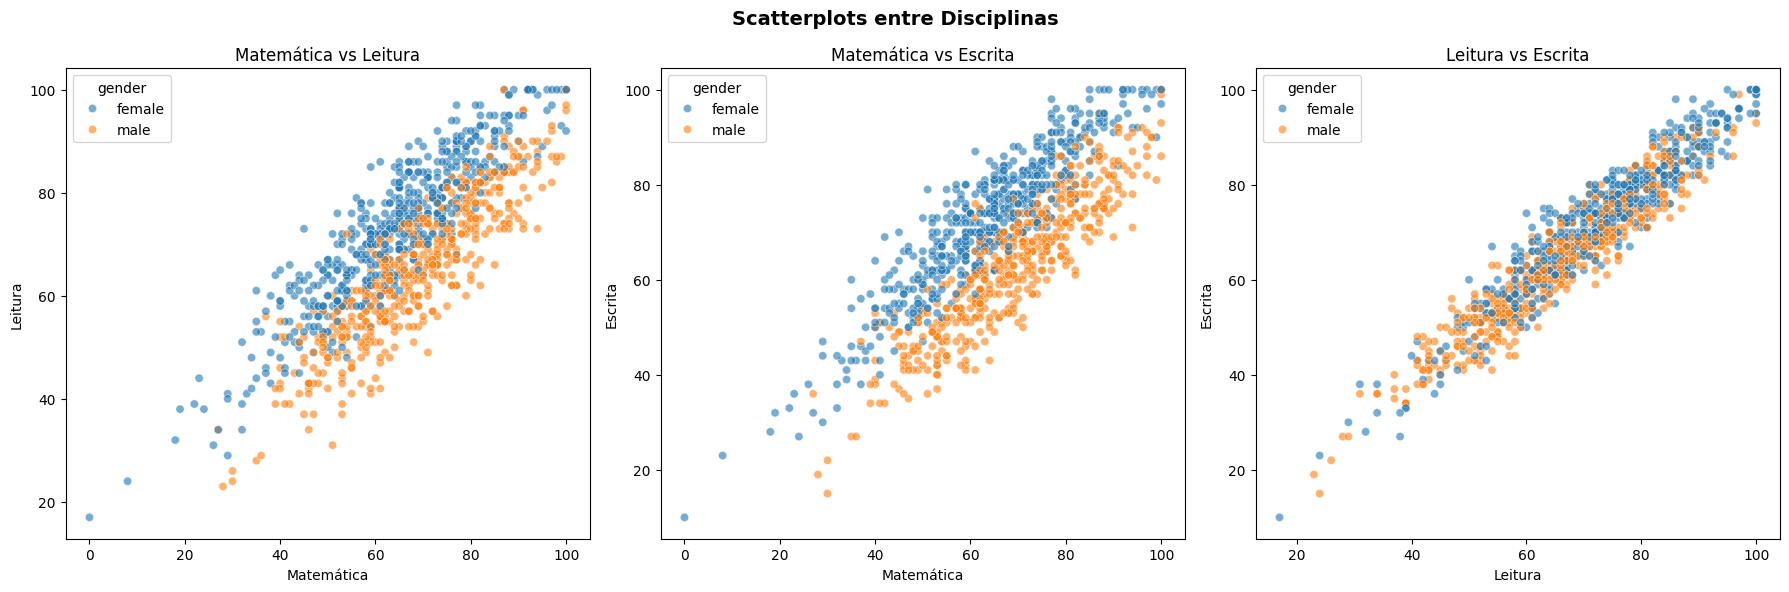

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pares = [('math score', 'reading score'),
         ('math score', 'writing score'),
         ('reading score', 'writing score')]
rotulos = [('Matemática', 'Leitura'),
           ('Matemática', 'Escrita'),
           ('Leitura', 'Escrita')]

for i, ((x, y), (rx, ry)) in enumerate(zip(pares, rotulos)):
    sns.scatterplot(data=base, x=x, y=y, hue='gender', alpha=0.6, ax=axes[i])
    axes[i].set_title(f'{rx} vs {ry}')
    axes[i].set_xlabel(rx)
    axes[i].set_ylabel(ry)

plt.suptitle('Scatterplots entre Disciplinas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
amostra_simples = base.sample(frac=0.1, random_state=42)
print(f"Tamanho da amostra: {len(amostra_simples)}")
print(f"\nMédia das notas na amostra:")
print(amostra_simples[disciplinas].mean().round(2))

Tamanho da amostra: 100

Média das notas na amostra:
math score       63.95
reading score    67.29
writing score    66.03
dtype: float64


In [48]:
amostra_estratificada = base.groupby('gender', group_keys=False).apply(
    lambda x: x.sample(frac=0.1, random_state=42))

print(f"Tamanho da amostra: {len(amostra_estratificada)} registros")
print(f"\nDistribuição por gênero na amostra:")
print(amostra_estratificada['gender'].value_counts())
print(f"\nMédia das notas por gênero na amostra:")
print(amostra_estratificada.groupby('gender')[disciplinas].mean().round(2))

Tamanho da amostra: 100 registros

Distribuição por gênero na amostra:
gender
female    52
male      48
Name: count, dtype: int64

Média das notas por gênero na amostra:
        math score  reading score  writing score
gender                                          
female       63.58          71.42          71.27
male         67.85          66.00          63.50


/tmp/ipykernel_2711/1872473854.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  amostra_estratificada = base.groupby('gender', group_keys=False).apply(


Conclusões

- As notas das três disciplinas seguem uma distribuição aproximadamente normal, com concentração em torno de 65-70 pontos.
- Alunas do gênero feminino tendem a ter notas mais altas em leitura e escrita, enquanto o gênero masculino apresenta desempenho superior em matemática.
- Alunos que completaram o curso preparatório apresentam notas consistentemente mais altas nas três disciplinas.
- Existe forte correlação positiva entre as notas das três disciplinas — alunos que vão bem em uma tendem a ir bem nas demais.

Medidas de centralidade e dispersão

In [21]:
print(f"{'Disciplina':<20} {'Média':>8} {'Mediana':>8} {'Moda':>8}")
print("-" * 48)

for col, titulo in zip(disciplinas, titulos):
    media   = base[col].mean()
    mediana = base[col].median()
    moda    = base[col].mode()[0]
    print(f"{titulo:<20} {media:>8.2f} {mediana:>8.2f} {moda:>8.2f}")

Disciplina              Média  Mediana     Moda
------------------------------------------------
Matemática              66.09    66.00    65.00
Leitura                 69.17    70.00    72.00
Escrita                 68.05    69.00    74.00


In [27]:

print(f"{'Disciplina':<20} {'Desv.Pad':>10} {'Variância':>10} {'CV (%)':>10}")
print("-" * 54)

for i, titulo in zip(disciplinas, titulos):
    dp  = base[i].std()
    var = base[i].var()
    cv  = (dp / base[i].mean()) * 100
    print(f"{titulo:<20} {dp:>10.2f} {var:>10.2f} {cv:>10.2f}")

print("\n💡 CV = Coeficiente de Variação (quanto menor, mais homogênea a turma)")

Disciplina             Desv.Pad  Variância     CV (%)
------------------------------------------------------
Matemática                15.16     229.92      22.94
Leitura                   14.60     213.17      21.11
Escrita                   15.20     230.91      22.33

💡 CV = Coeficiente de Variação (quanto menor, mais homogênea a turma)


In [28]:
#Média das notas por Gênero

print(base.groupby('gender')[disciplinas].mean().round(2))

print("\n Média das notas por Curso Preparatório:\n")
print(base.groupby('test preparation course')[disciplinas].mean().round(2))

        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31

 Média das notas por Curso Preparatório:

                         math score  reading score  writing score
test preparation course                                          
completed                     69.70          73.89          74.42
none                          64.08          66.53          64.50


In [37]:
#Quartis das notas
quartis = base[disciplinas].quantile([0.25, 0.50, 0.75])
quartis.index = ['Q1 (25%)', 'Q2 (50%)', 'Q3 (75%)']
print(quartis.round(2))

#Valores máximos e mínimos
print('-'*50)
print(base[disciplinas].agg(['min', 'max']))

          math score  reading score  writing score
Q1 (25%)        57.0           59.0          57.75
Q2 (50%)        66.0           70.0          69.00
Q3 (75%)        77.0           79.0          79.00
--------------------------------------------------
     math score  reading score  writing score
min           0             17             10
max         100            100            100


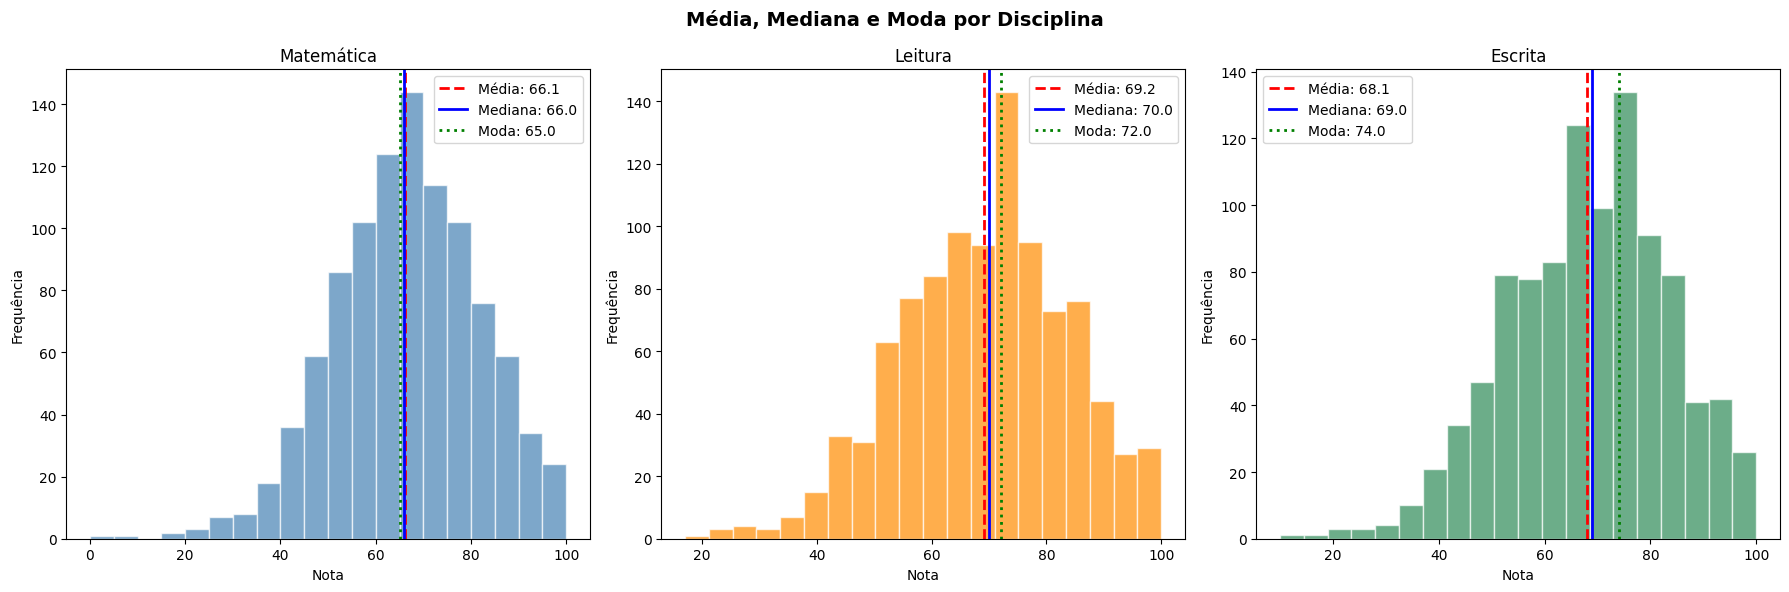

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, titulo, cor) in enumerate(zip(disciplinas, titulos, cores)):
    axes[i].hist(base[col], bins=20, color=cor, edgecolor='white', alpha=0.7)
    axes[i].axvline(base[col].mean(),   color='red',    linestyle='--', linewidth=2, label=f'Média: {base[col].mean():.1f}')
    axes[i].axvline(base[col].median(), color='blue',   linestyle='-',  linewidth=2, label=f'Mediana: {base[col].median():.1f}')
    axes[i].axvline(base[col].mode()[0],color='green',  linestyle=':',  linewidth=2, label=f'Moda: {base[col].mode()[0]:.1f}')
    axes[i].set_title(titulo)
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Frequência')
    axes[i].legend()

plt.suptitle('Média, Mediana e Moda por Disciplina', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Conclusões
- As médias das três disciplinas ficam entre 66 e 69 pontos, indicando desempenho moderado geral.
- A proximidade entre média e mediana em todas as disciplinas confirma distribuições aproximadamente simétricas.
- Matemática apresenta o maior coeficiente de variação, indicando maior desigualdade de desempenho entre os alunos.
- Alunos que completaram o curso preparatório têm médias entre 8 e 10 pontos acima dos que não completaram.